In [67]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

## -Como estão as vendas da empresa e quais são os principais pontos que a empresa deveria conhecer sobre seus produtos, clientes e vendas?

In [6]:
tabela=pd.read_csv('ecommerce_sales_analytics_5000.csv')
display(tabela)
display(tabela.info())

,order_id,order_date,customer_id,product_category,region,quantity,unit_price,discount,payment_method,delivery_days,customer_rating,revenue
0,10001,1/1/2022,1102,Beauty,South,7,373.65,0.28,Wallet,10,4.7,1883.20
1,10002,1/2/2022,1435,Clothing,South,7,47.74,0.09,Card,6,3.9,304.10
2,10003,1/3/2022,1860,Beauty,East,3,311.28,0.31,COD,6,2.5,644.35
3,10004,1/4/2022,1270,Electronics,West,5,524.47,0.02,Wallet,6,1.6,2569.90
4,10005,1/5/2022,1106,Clothing,West,5,139.87,0.33,Wallet,4,4.9,468.56
...,...,...,...,...,...,...,...,...,...,...,...,...
4995,14996,9/5/2035,1289,Clothing,West,2,371.74,0.27,COD,3,2.3,542.74
4996,14997,9/6/2035,1294,Beauty,North,3,553.67,0.14,COD,11,2.2,1428.47
4997,14998,9/7/2035,1450,Beauty,West,3,77.22,0.24,Wallet,6,3.4,176.06
4998,14999,9/8/2035,1903,Electronics,South,4,138.41,0.21,COD,4,2.8,437.38


<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          5000 non-null   int64  
 1   order_date        5000 non-null   str    
 2   customer_id       5000 non-null   int64  
 3   product_category  5000 non-null   str    
 4   region            5000 non-null   str    
 5   quantity          5000 non-null   int64  
 6   unit_price        5000 non-null   float64
 7   discount          5000 non-null   float64
 8   payment_method    5000 non-null   str    
 9   delivery_days     5000 non-null   int64  
 10  customer_rating   5000 non-null   float64
 11  revenue           5000 non-null   float64
dtypes: float64(4), int64(4), str(4)
memory usage: 468.9 KB


None

## Limpando a base de dados

In [21]:
tabela=tabela.drop_duplicates()
print(tabela.info())

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          5000 non-null   int64  
 1   order_date        5000 non-null   str    
 2   customer_id       5000 non-null   int64  
 3   product_category  5000 non-null   str    
 4   region            5000 non-null   str    
 5   quantity          5000 non-null   int64  
 6   unit_price        5000 non-null   float64
 7   discount          5000 non-null   float64
 8   payment_method    5000 non-null   str    
 9   delivery_days     5000 non-null   int64  
 10  customer_rating   5000 non-null   float64
 11  revenue           5000 non-null   float64
dtypes: float64(4), int64(4), str(4)
memory usage: 468.9 KB
None


## Preço Médio dos produtos

In [ ]:
preco_medio=tabela['unit_price'].mean()
print('O preço médio dos produtos é de {:.2f}R$'.format(preco_medio))

O preço médio dos produtos é de 308.42R$


## Maior Preço

In [28]:
maior_preco=tabela['unit_price'].max()
print('O produto mias caro custa {:.2f}R$'.format(maior_preco))

O produto mias caro custa 599.96R$


## Menor preço

In [29]:
menor_preco=tabela['unit_price'].min()
print('O produto mias barato custa {:.2f}R$'.format(menor_preco))

O produto mias barato custa 15.15R$


## Tempo médio de entrega

In [35]:
media_entrega=tabela['delivery_days'].mean()
print('Em média o pedido demora {:.0f} dias para serem entreges'.format(media_entrega))

Em média o pedido demora 6 dias para serem entreges


## Faturamento total

In [48]:
faturamento=tabela['revenue'].sum()
print(('O faturamento total é de {:,.2f}R$'.format(faturamento)).replace(',', 'X').replace('.', ',').replace('X', '.'))

O faturamento total é de 5.109.775,74R$


## Quais categorias possuem mais pedidos

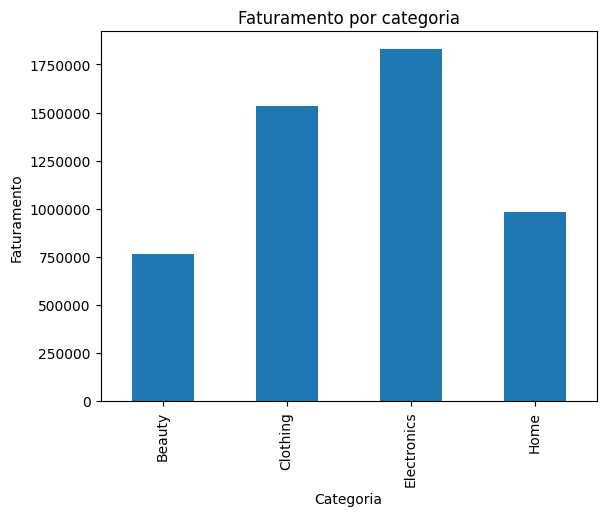

In [ ]:
mais_pedido=tabela.groupby('product_category')['revenue'].sum()
mais_pedido.plot.bar()

plt.gca().yaxis.set_major_formatter(ScalarFormatter())

plt.ticklabel_format(style='plain', axis='y')

plt.title('Faturamento por categoria')
plt.xlabel('Categoria')
plt.ylabel('Faturamento')
plt.show()

## Categoria que vende mais produtos

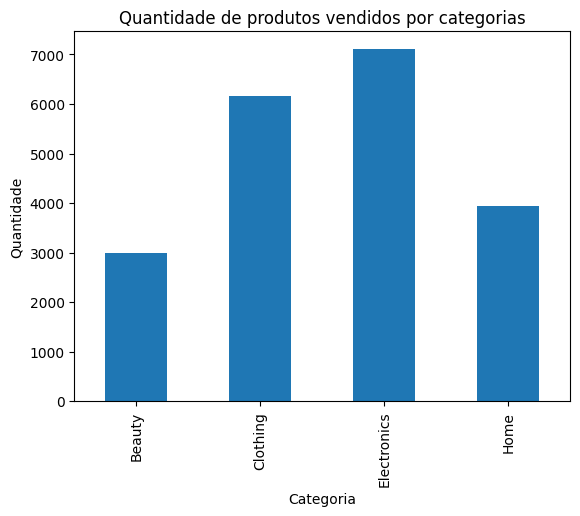

In [72]:
categoria_venda_produto=tabela.groupby('product_category')['quantity'].sum()
categoria_venda_produto.plot.bar()

plt.gca().yaxis.set_major_formatter(ScalarFormatter())

plt.ticklabel_format(style='plain', axis='y')

plt.title('Quantidade de produtos vendidos por categorias')
plt.xlabel('Categoria')
plt.ylabel('Quantidade')
plt.show()

## Região com mais pedidos

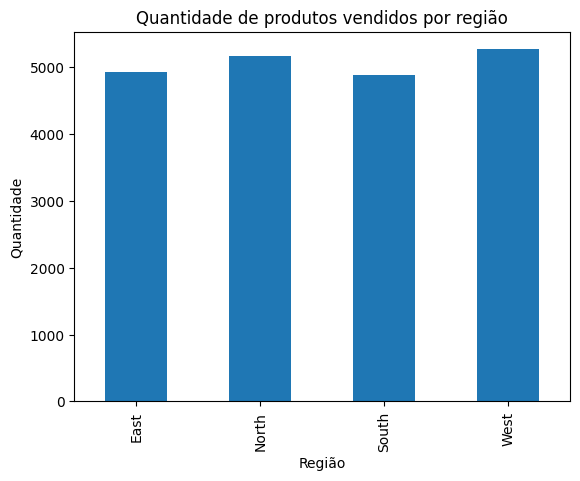

In [75]:
pedidos_regiao=tabela.groupby('region')['quantity'].sum()
pedidos_regiao.plot.bar()

plt.gca().yaxis.set_major_formatter(ScalarFormatter())

plt.ticklabel_format(style='plain', axis='y')

plt.title('Quantidade de produtos vendidos por região')
plt.xlabel('Região')
plt.ylabel('Quantidade')
plt.show()

## Faturamento ao longo dos anos

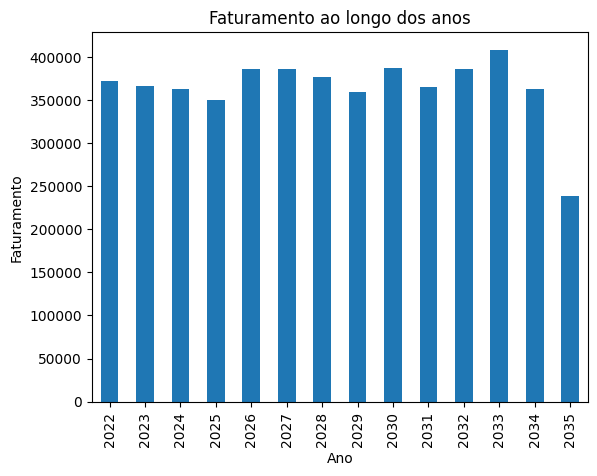

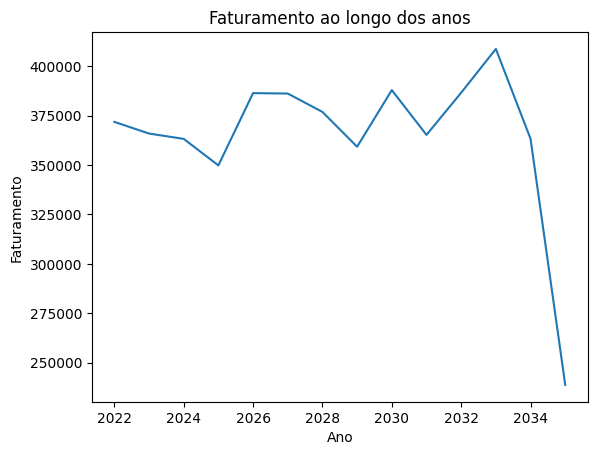

In [109]:
tabela['order_date'] = pd.to_datetime(tabela['order_date'])
tabela['ano'] = tabela['order_date'].dt.year

ano_faturamento=tabela.groupby('ano')['revenue'].sum()
ano_faturamento.plot.bar()

plt.gca().yaxis.set_major_formatter(ScalarFormatter())

plt.ticklabel_format(style='plain', axis='y')

plt.title('Faturamento ao longo dos anos')
plt.xlabel('Ano')
plt.ylabel('Faturamento')
plt.show()

ano_faturamento.plot()

plt.gca().yaxis.set_major_formatter(ScalarFormatter())

plt.ticklabel_format(style='plain', axis='y')

plt.title('Faturamento ao longo dos anos')
plt.xlabel('Ano')
plt.ylabel('Faturamento')
plt.show()

## Relação entre as categorias

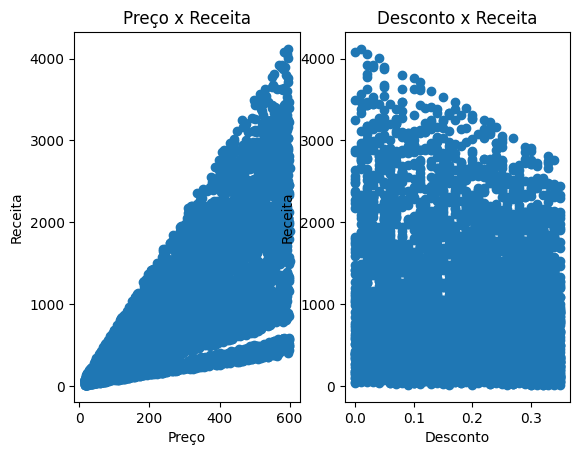

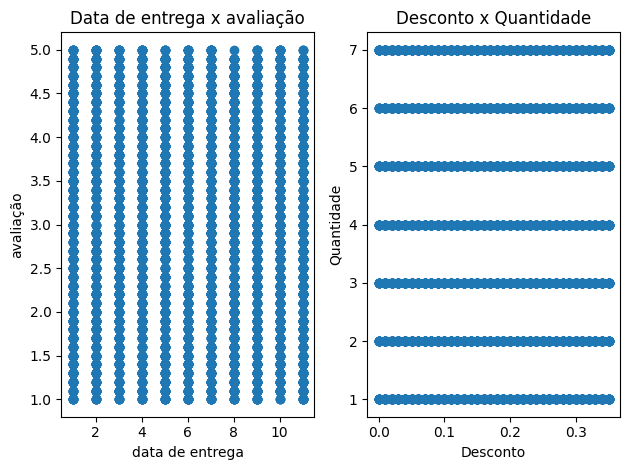

In [106]:
fig, ax = plt.subplots(1, 2,)

ax[0].scatter(tabela['unit_price'], tabela['revenue'])
ax[0].set_title('Preço x Receita')
ax[0].set_xlabel('Preço')
ax[0].set_ylabel('Receita')

ax[1].scatter(tabela['discount'], tabela['revenue'])
ax[1].set_title('Desconto x Receita')
ax[1].set_xlabel('Desconto')
ax[1].set_ylabel('Receita')

fig, ax = plt.subplots(1, 2,)
ax[0].scatter(tabela['delivery_days'], tabela['customer_rating'])
ax[0].set_title('Data de entrega x avaliação')
ax[0].set_xlabel('data de entrega')
ax[0].set_ylabel('avaliação')

ax[1].scatter(tabela['discount'], tabela['quantity'])
ax[1].set_title('Desconto x Quantidade')
ax[1].set_xlabel('Desconto')
ax[1].set_ylabel('Quantidade')

plt.tight_layout()
plt.show()

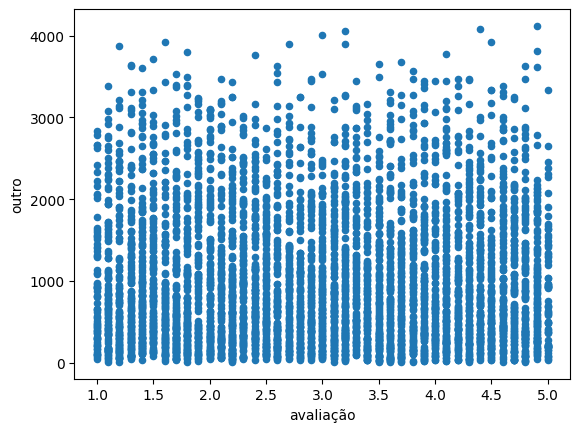

In [120]:
tabela.plot.scatter(x='customer_rating', y='revenue')

plt.xlabel('avaliação')
plt.ylabel('outro')
plt.show()

##### Ao analisar o faturamento ao longo dos anos, observa-se que as vendas permaneceram relativamente estáveis durante a maior parte do período, com uma queda mais acentuada em 2035. Em relação às categorias de produtos, Beleza e Cuidados Pessoais e produtos para Casa apresentaram menor desempenho em comparação com Eletrônicos e Roupas. Dessa forma, seria interessante avaliar a possibilidade de direcionar uma parcela maior dos investimentos para as categorias que apresentam maior faturamento, especialmente Eletrônicos e Roupas, sem deixar de investigar os motivos do baixo desempenho das demais categorias.

##### Também não foi identificada uma relação significativa entre as avaliações dos clientes e as demais variáveis analisadas, como preço, desconto, quantidade de produtos e prazo de entrega. Isso indica que, nessa base de dados, essas variáveis não parecem ter uma influência clara sobre a avaliação dada pelos clientes.